In [25]:
import pandas as pd

DATA_ROOT = '../../data/Full data files'
GRN_ROOT = './data'

In [26]:
Gene_expressions = pd.read_csv('/home/alexanderb/Zhang_lab/data/Full data files/ARCHS4_healthy_log_noFMExternal.tsv', sep = '\t', index_col = 0)

In [42]:
genes_expressed = set(Gene_expressions.columns)

In [43]:
GRN = pd.read_csv(f'{GRN_ROOT}/inferred_GRN.csv', index_col = 0)

In [44]:
all_TFs = set(GRN["TF"])

In [45]:
TF = 'EGR1'

In [46]:
FOXA2_target = pd.read_csv(f"/home/alexanderb/Zhang_lab/data/Full data files/CHiP seq/{TF}_Liver.txt", sep = '\t')

In [47]:
def get_percentage_of_cistrome(threshold, GRN, cistrome_df, genes_in_dataset, target = 'FOXA2'):
    '''
    Get the percentage of the cistrome putative targets of a TF that are also inferred by GRN inference approach for a given cistrome RP threshold.
    GRN must be subset such that the to only the TF being evaluated
    '''
    #filter df based on threshold
    cistrome_df = cistrome_df[cistrome_df['score'] > threshold]
    #get just the putative targets from cistrome df
    cistrome_targets = set(cistrome_df['symbol'])
    #get the cistrome targets that are also in the dataset used for model creation
    cistrome_in_dataset = genes_in_dataset & cistrome_targets

    #get all inferred TFs
    all_TFs = set(GRN["TF"])
    #subset GRN to target gene
    target_GRN = GRN[(GRN['TF'] == target)]

    #get inferred targets from inferred GRN
    inferred_targets = set(target_GRN['Gene'])
    
    
    #sanity check remove TF
    inferred_targets = inferred_targets - set('FOXA2')
    #get the inferred targets that are also cistrome targets
    inferred_and_cistrome = inferred_targets & cistrome_in_dataset

    print(f"There are {len(inferred_targets)} inferred targets of {target}")
    print(f"At a threshold of {threshold} there are {len(cistrome_in_dataset)} cistrome putative targets of {target} (that are also in the dataset)")
    print(f"This is {len(cistrome_in_dataset)/len(genes_expressed)} of all TFs in the dataset")
    print(f"{len(inferred_and_cistrome)} genes are both inferred and cistrome targets (at this threshold)")
    print(f"This is {len(inferred_and_cistrome)/len(cistrome_targets)} of the cistrome targets at this threshold")
    print("\n")
    

    return(len(inferred_and_cistrome) / len(cistrome_in_dataset), (len(cistrome_in_dataset)/len(genes_expressed)))

In [48]:
#filter to a putative score > 1
threshold = 0
FOXA2_target = FOXA2_target[FOXA2_target['score'] > threshold]

In [49]:
FOXA2_cistrome_targets = set(FOXA2_target['symbol'])

In [50]:
FOXA2_cistrome_in_dataset = genes_expressed & FOXA2_cistrome_targets

In [ ]:
FOXA2_GRN = GRN[(GRN['TF'] == TF)]
FOXA2_inferred_targets = set(FOXA2_GRN['Gene'])
FOXA2_inferred_targets = FOXA2_inferred_targets - set(TF)

In [52]:
print(f'There are {len(FOXA2_inferred_targets & FOXA2_cistrome_in_dataset)} inferred regulators that are also potential targets as defined by ChIP seq analysis from CistromeDB. There are {len(FOXA2_cistrome_in_dataset)} cistrome targets in the overall dataset. \n The percentage of cistrome putative targets we infer is therefore {(len(FOXA2_inferred_targets & FOXA2_cistrome_in_dataset)/len(FOXA2_cistrome_in_dataset))*100}')

There are 2176 inferred regulators that are also potential targets as defined by ChIP seq analysis from CistromeDB. There are 12713 cistrome targets in the overall dataset. 
 The percentage of cistrome putative targets we infer is therefore 17.116337607173758


In [53]:
print(f'The percentage of TFs in the dataset that are cistrome putative targets is {len(FOXA2_cistrome_targets)/len(all_TFs)}')

The percentage of TFs in the dataset that are cistrome putative targets is 13.132093023255814


In [54]:
percentage_of_cistromes = []
cistrome_percentage_of_background = []
thresholds = [0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
for threshold in thresholds:
    percentage_of_cistromes.append(get_percentage_of_cistrome(threshold, FOXA2_GRN, FOXA2_target, genes_expressed, target = TF)[0])
    cistrome_percentage_of_background.append(get_percentage_of_cistrome(threshold, FOXA2_GRN, FOXA2_target, genes_expressed, target = TF)[1])

There are 2870 inferred targets of EGR1
At a threshold of 0 there are 12713 cistrome putative targets of EGR1 (that are also in the dataset)
This is 0.4336243945698888 of all TFs in the dataset
2176 genes are both inferred and cistrome targets (at this threshold)
This is 0.15414039810157965 of the cistrome targets at this threshold


There are 2870 inferred targets of EGR1
At a threshold of 0 there are 12713 cistrome putative targets of EGR1 (that are also in the dataset)
This is 0.4336243945698888 of all TFs in the dataset
2176 genes are both inferred and cistrome targets (at this threshold)
This is 0.15414039810157965 of the cistrome targets at this threshold


There are 2870 inferred targets of EGR1
At a threshold of 0.1 there are 9060 cistrome putative targets of EGR1 (that are also in the dataset)
This is 0.30902517224913023 of all TFs in the dataset
1596 genes are both inferred and cistrome targets (at this threshold)
This is 0.16300684301909918 of the cistrome targets at this th

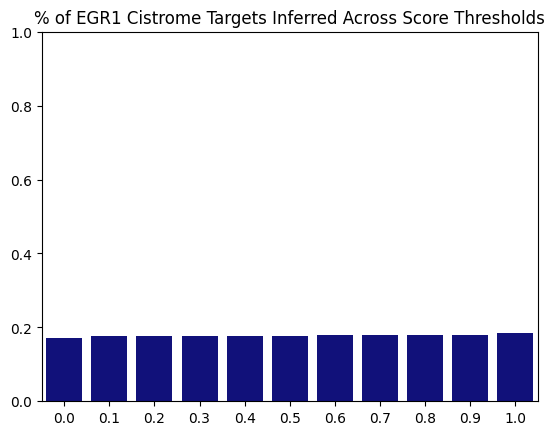

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.barplot(x = thresholds, y = percentage_of_cistromes, color = 'darkblue')
plt.title(f'% of {TF} Cistrome Targets Inferred Across Score Thresholds')
plt.ylim(0, 1)
plt.savefig(f'./figures/{TF}_binding_validiation', dpi = 300, bbox_inches = 'tight')